<h2>Data Analytics- notebook, Compost coders</h2>

<h4><b>Dataset name: Short description</b></h4>

Dataset analysis about Lapin AMK composters

<h4><b>Data source (url):</b></h4>

https://kuituhamppu.frostbit.fi/composting/measurements

<h4><b>Data format:</b></h4>

Describe file structure here.

<h4><b>Data description, features and limitations:</b></h4>

NOTE: AI has been used heavily in this notebook to help create code and analyse data

<h3 style="color: red"><b>Code: importing modules, custom functions and loading the data</b></h3>

In [217]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [218]:
# Load the dataset
df = pd.read_csv('../../data/combined_compost_measurements.csv')

<h3 style="color: red"><b>Code: Data clean-up procedure</b></h3>

In [219]:
df.columns

Index(['Day', 'Compost 1-Inside-Heating - kWh', 'Compost 1-Inside-Heating - w',
       'Compost 1-Lower-Moisture', 'Compost 1-Lower-Temperature',
       'Compost 1-Middle-Moisture', 'Compost 1-Middle-Temperature',
       'Compost 1-Upper-Moisture', 'Compost 1-Upper-Temperature',
       'Compost 2-Inside-Heating - kWh', 'Compost 2-Inside-Heating - w',
       'Compost 2-Lower-Moisture', 'Compost 2-Lower-Temperature',
       'Compost 2-Middle-Moisture', 'Compost 2-Middle-Temperature',
       'Compost 2-Upper-Moisture', 'Compost 2-Upper-Temperature',
       'Growing-18E0-Moisture', 'Growing-18E0-Temperature',
       'Growing-4B21-Moisture', 'Growing-4B21-Temperature',
       'Growing-5D20-Moisture', 'Growing-5D20-Temperature',
       'Growing-E43B-Moisture', 'Growing-E43B-Temperature',
       'Growing-R9A5E-Moisture', 'Growing-R9A5E-Temperature',
       'Growing-Sensor 01-Moisture', 'Growing-Sensor 02-Moisture',
       'Growing-Sensor 03-Moisture', 'Growing-Sensor 04-Moisture',
       'Gro

In [220]:
# Convert 'Day' column to datetime format
df['Day'] = pd.to_datetime(df['Day'])

In [221]:
# Drop Growing experiment columns and kWh columns
df.drop(df.filter(like="Growing").columns, axis=1, inplace=True)
df.drop(["Compost 1-Inside-Heating - kWh", "Compost 2-Inside-Heating - kWh"], axis=1, inplace=True)

In [222]:
# Shorten string names in columns for easier handling
df.columns = df.columns.str.replace('Compost 1-', 'C1_')
df.columns = df.columns.str.replace('Compost 2-', 'C2_')
df.columns = df.columns.str.replace('Outside-Outside-', 'Out_')
df.columns = df.columns.str.replace('Inside', 'Inside')
df.columns = df.columns.str.replace('Shed-Shed-', 'shed_')
df.columns = df.columns.str.replace('-', '_')
df.columns = df.columns.str.replace('Upper', 'Up')
df.columns = df.columns.str.replace('Lower', 'Low')
df.columns = df.columns.str.replace('Middle', 'Mid')
df.columns = df.columns.str.replace('Temperature', 'T')
df.columns = df.columns.str.replace('Moisture', 'M')
df.columns = df.columns.str.replace('Heating', 'heat')
df.columns = df.columns.str.replace(' ', '')


In [223]:
df = df[df['Day'] < '2025-08-01']

In [224]:
df.columns

Index(['Day', 'C1_Inside_heat_w', 'C1_Low_M', 'C1_Low_T', 'C1_Mid_M',
       'C1_Mid_T', 'C1_Up_M', 'C1_Up_T', 'C2_Inside_heat_w', 'C2_Low_M',
       'C2_Low_T', 'C2_Mid_M', 'C2_Mid_T', 'C2_Up_M', 'C2_Up_T', 'Out_M',
       'Out_T', 'shed_M', 'shed_T'],
      dtype='str')

<h3 style="color: red"><b>Code: Data analysis</b></h3>

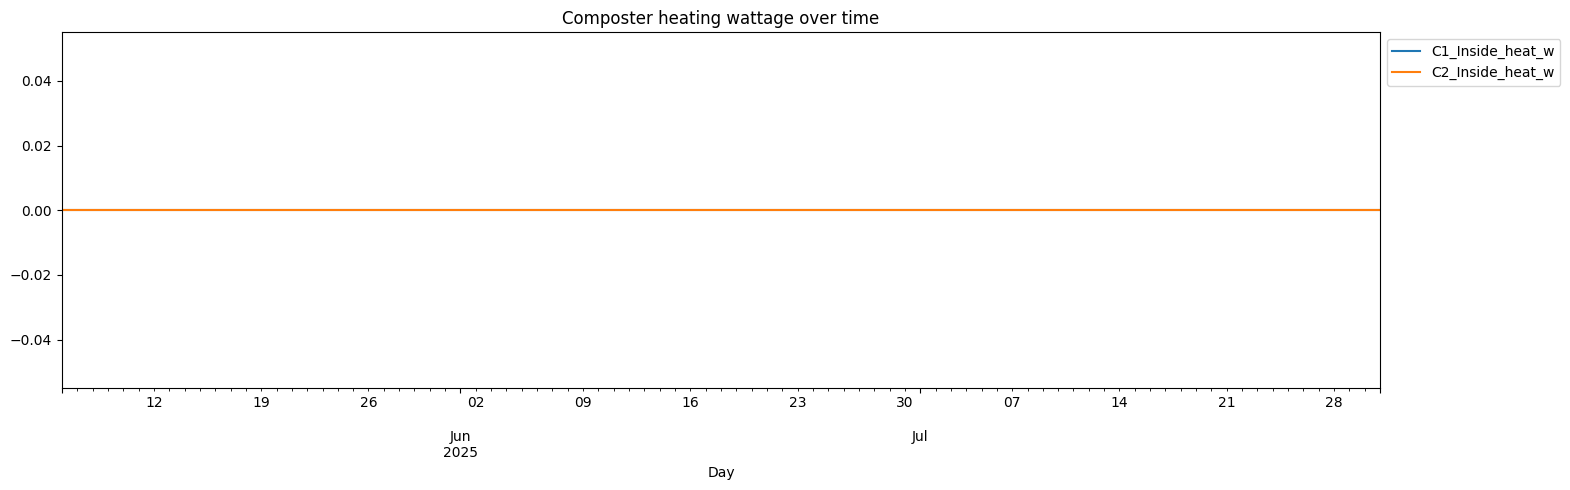

In [225]:
cols = [col for col in df.columns if col.startswith('') and col.endswith('w')]

df.set_index('Day')[cols].plot(figsize=(14, 5), title='Composter heating wattage over time')
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

### Composter 1

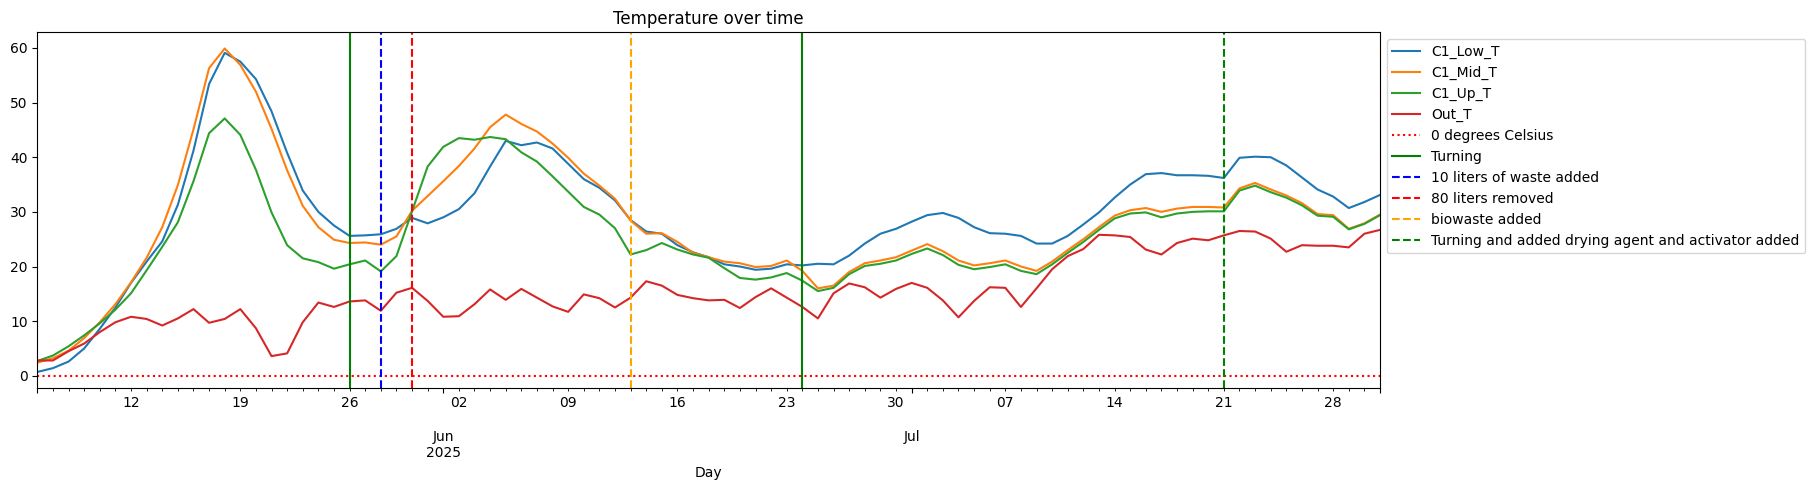

In [226]:
cols = [col for col in df.columns if col.startswith('C1') and col.endswith('T') or col.startswith('Out_T')]

df.set_index('Day')[cols].plot(figsize=(14, 5), title='Temperature over time')
plt.tight_layout()
plt.axhline(y=0, color='r', linestyle=':', label='0 degrees Celsius')
plt.axvline(x=pd.to_datetime('2025-05-26'), color='g', linestyle='-', label='Turning')
plt.axvline(x=pd.to_datetime('2025-05-28'), color='b', linestyle='--', label='10 liters of waste added')
plt.axvline(x=pd.to_datetime('2025-05-30'), color='r', linestyle='--', label='80 liters removed')
plt.axvline(x=pd.to_datetime('2025-06-13'), color='orange', linestyle='--', label='biowaste added')
plt.axvline(x=pd.to_datetime('2025-06-24'), color='g', linestyle='-')
plt.axvline(x=pd.to_datetime('2025-07-21'), color='g', linestyle='--', label='Turning and added drying agent and activator added')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

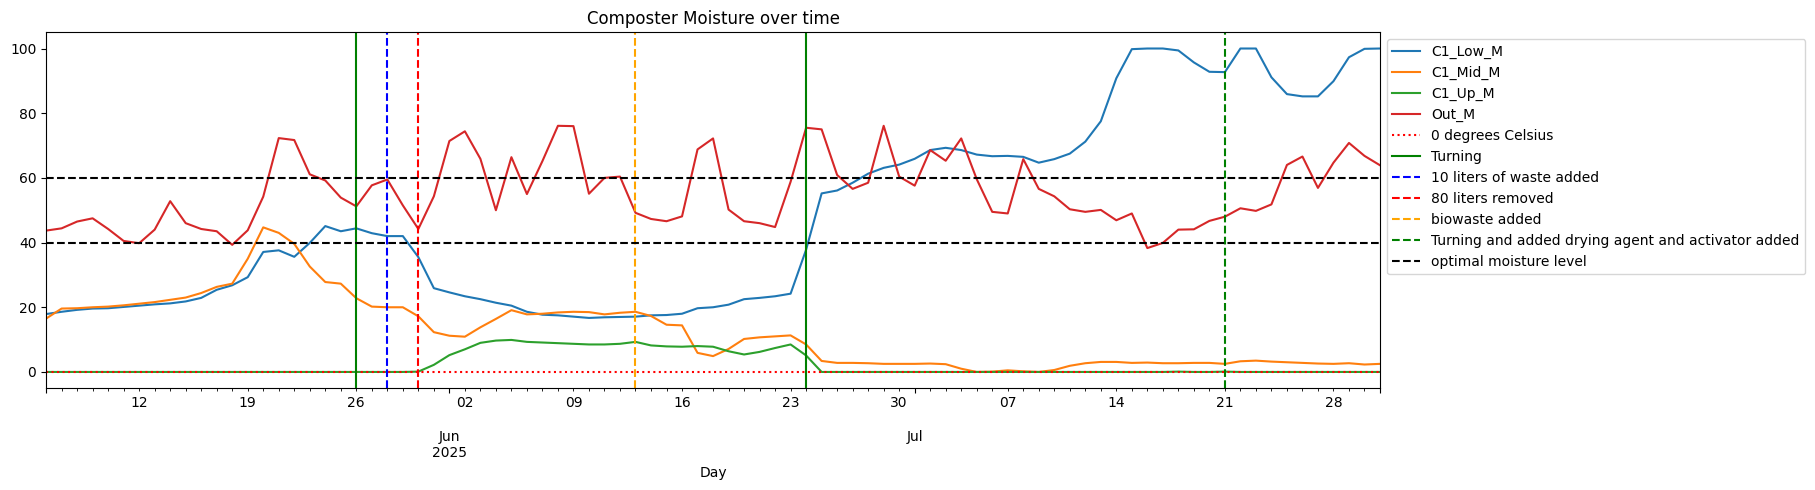

In [227]:
cols = [col for col in df.columns if col.startswith('C1') and col.endswith('M') or col.startswith('Out_M')]

df.set_index('Day')[cols].plot(figsize=(14, 5), title='Composter Moisture over time')
plt.tight_layout()
plt.axhline(y=0, color='r', linestyle=':', label='0 degrees Celsius')
plt.axvline(x=pd.to_datetime('2025-05-26'), color='g', linestyle='-', label='Turning')
plt.axvline(x=pd.to_datetime('2025-05-28'), color='b', linestyle='--', label='10 liters of waste added')
plt.axvline(x=pd.to_datetime('2025-05-30'), color='r', linestyle='--', label='80 liters removed')
plt.axvline(x=pd.to_datetime('2025-06-13'), color='orange', linestyle='--', label='biowaste added')
plt.axvline(x=pd.to_datetime('2025-06-24'), color='g', linestyle='-')
plt.axvline(x=pd.to_datetime('2025-07-21'), color='g', linestyle='--', label='Turning and added drying agent and activator added')
plt.axhline(y=40, color='black', linestyle='--', label='optimal moisture level')
plt.axhline(y=60, color='black', linestyle='--')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

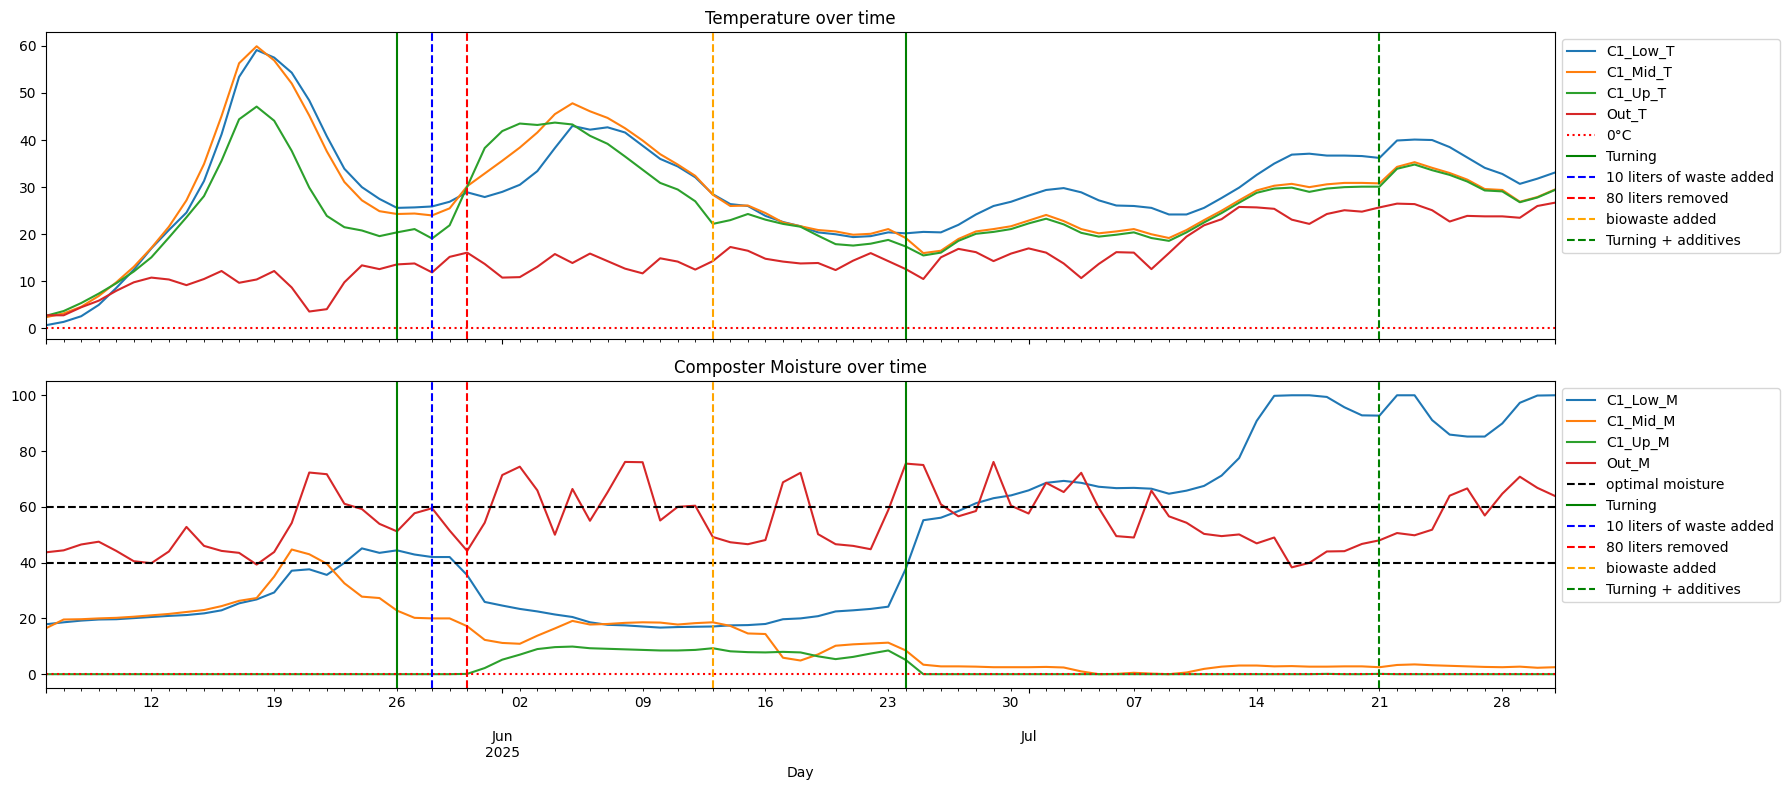

In [228]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# ---- Temperature plot ----
cols_T = [col for col in df.columns if (col.startswith('C1') and col.endswith('T')) or col.startswith('Out_T')]
df.set_index('Day')[cols_T].plot(ax=axes[0], title='Temperature over time')

axes[0].axhline(y=0, color='r', linestyle=':', label='0°C')

# Vertical lines (reuse later too)
vlines = [
    ('2025-05-26', 'g', '-', 'Turning'),
    ('2025-05-28', 'b', '--', '10 liters of waste added'),
    ('2025-05-30', 'r', '--', '80 liters removed'),
    ('2025-06-13', 'orange', '--', 'biowaste added'),
    ('2025-06-24', 'g', '-', None),
    ('2025-07-21', 'g', '--', 'Turning + additives')
]

for date, color, style, label in vlines:
    axes[0].axvline(pd.to_datetime(date), color=color, linestyle=style, label=label)

axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))


# ---- Moisture plot ----
cols_M = [col for col in df.columns if (col.startswith('C1') and col.endswith('M')) or col.startswith('Out_M')]
df.set_index('Day')[cols_M].plot(ax=axes[1], title='Composter Moisture over time')

axes[1].axhline(y=0, color='r', linestyle=':')
axes[1].axhline(y=40, color='black', linestyle='--', label='optimal moisture')
axes[1].axhline(y=60, color='black', linestyle='--')

for date, color, style, label in vlines:
    axes[1].axvline(pd.to_datetime(date), color=color, linestyle=style, label=label)

axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))


plt.tight_layout()
plt.show()

### Composter 2

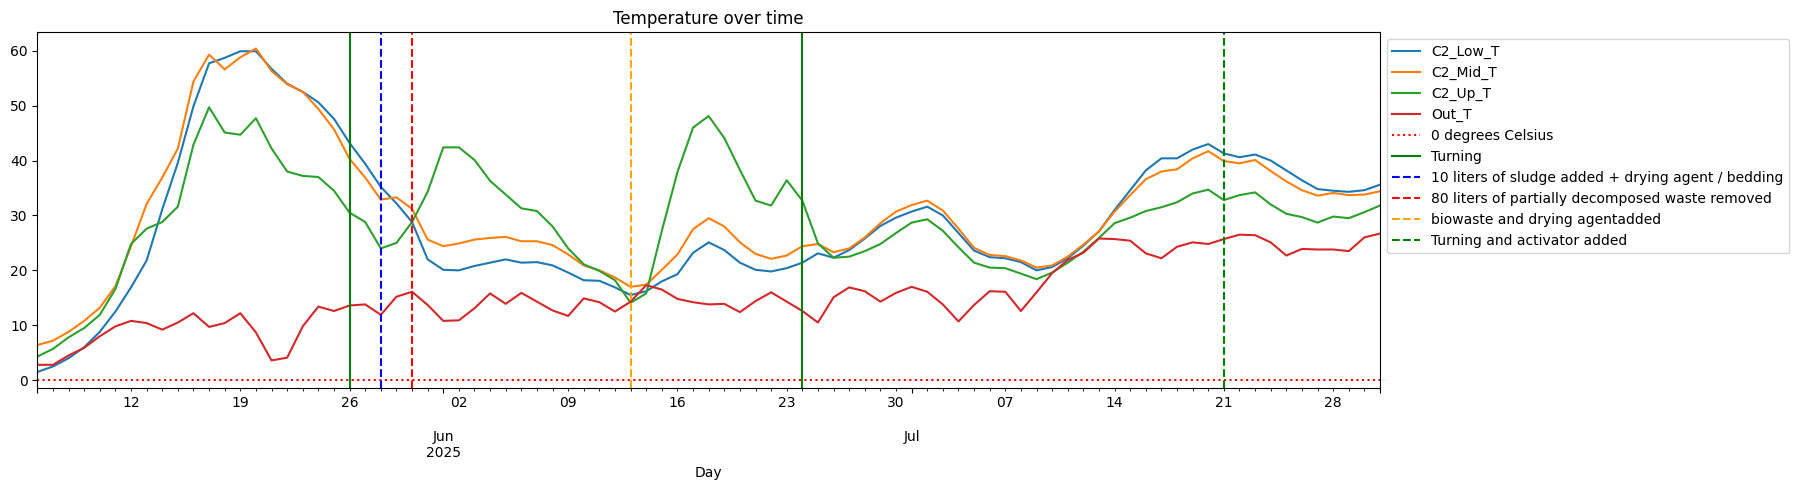

In [229]:
cols = [col for col in df.columns if col.startswith('C2') and col.endswith('T') or col.startswith('Out_T')]

df.set_index('Day')[cols].plot(figsize=(14, 5), title='Temperature over time')
plt.tight_layout()
plt.axhline(y=0, color='r', linestyle=':', label='0 degrees Celsius')
plt.axvline(x=pd.to_datetime('2025-05-26'), color='g', linestyle='-', label='Turning')
plt.axvline(x=pd.to_datetime('2025-05-28'), color='b', linestyle='--', label='10 liters of sludge added + drying agent / bedding')
plt.axvline(x=pd.to_datetime('2025-05-30'), color='r', linestyle='--', label='80 liters of partially decomposed waste removed')
plt.axvline(x=pd.to_datetime('2025-06-13'), color='orange', linestyle='--', label='biowaste and drying agentadded')
plt.axvline(x=pd.to_datetime('2025-06-24'), color='g', linestyle='-')
plt.axvline(x=pd.to_datetime('2025-07-21'), color='g', linestyle='--', label='Turning and activator added')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

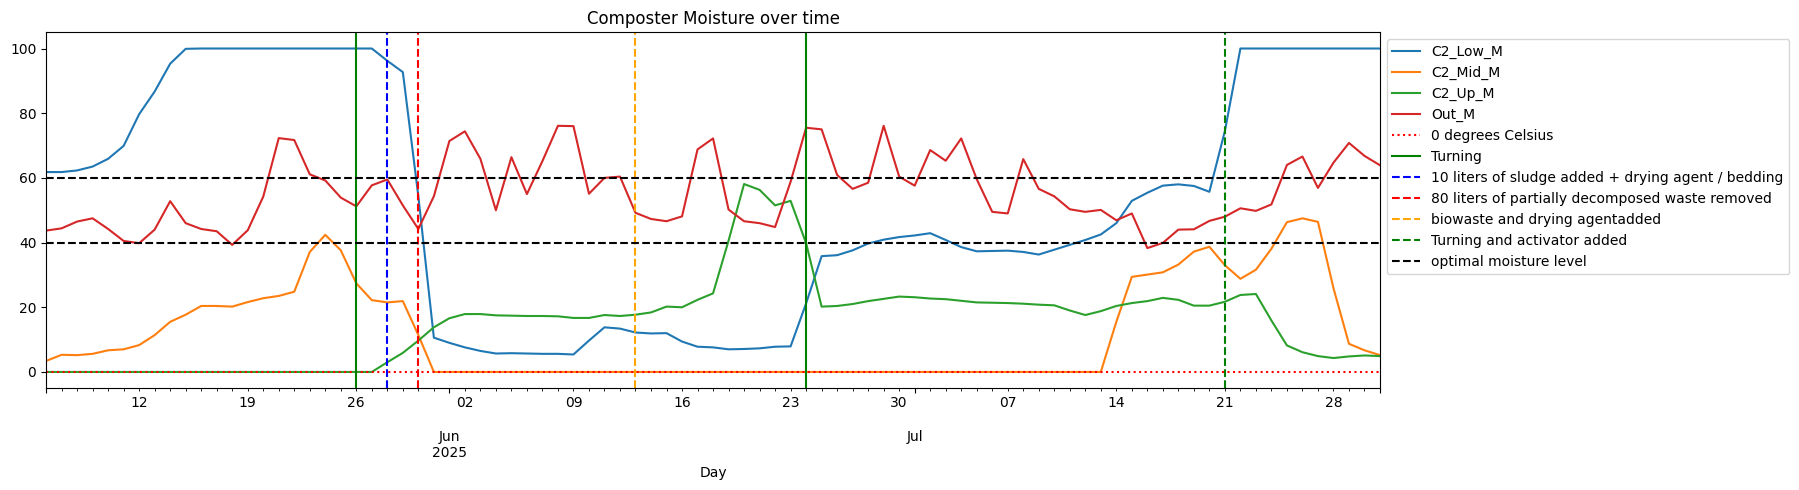

In [230]:
cols = [col for col in df.columns if col.startswith('C2') and col.endswith('M') or col.startswith('Out_M')]

df.set_index('Day')[cols].plot(figsize=(14, 5), title='Composter Moisture over time')
plt.tight_layout()
plt.axhline(y=0, color='r', linestyle=':', label='0 degrees Celsius')
plt.axvline(x=pd.to_datetime('2025-05-26'), color='g', linestyle='-', label='Turning')
plt.axvline(x=pd.to_datetime('2025-05-28'), color='b', linestyle='--', label='10 liters of sludge added + drying agent / bedding')
plt.axvline(x=pd.to_datetime('2025-05-30'), color='r', linestyle='--', label='80 liters of partially decomposed waste removed')
plt.axvline(x=pd.to_datetime('2025-06-13'), color='orange', linestyle='--', label='biowaste and drying agentadded')
plt.axvline(x=pd.to_datetime('2025-06-24'), color='g', linestyle='-')
plt.axvline(x=pd.to_datetime('2025-07-21'), color='g', linestyle='--', label='Turning and activator added')
plt.axhline(y=40, color='black', linestyle='--', label='optimal moisture level')
plt.axhline(y=60, color='black', linestyle='--')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

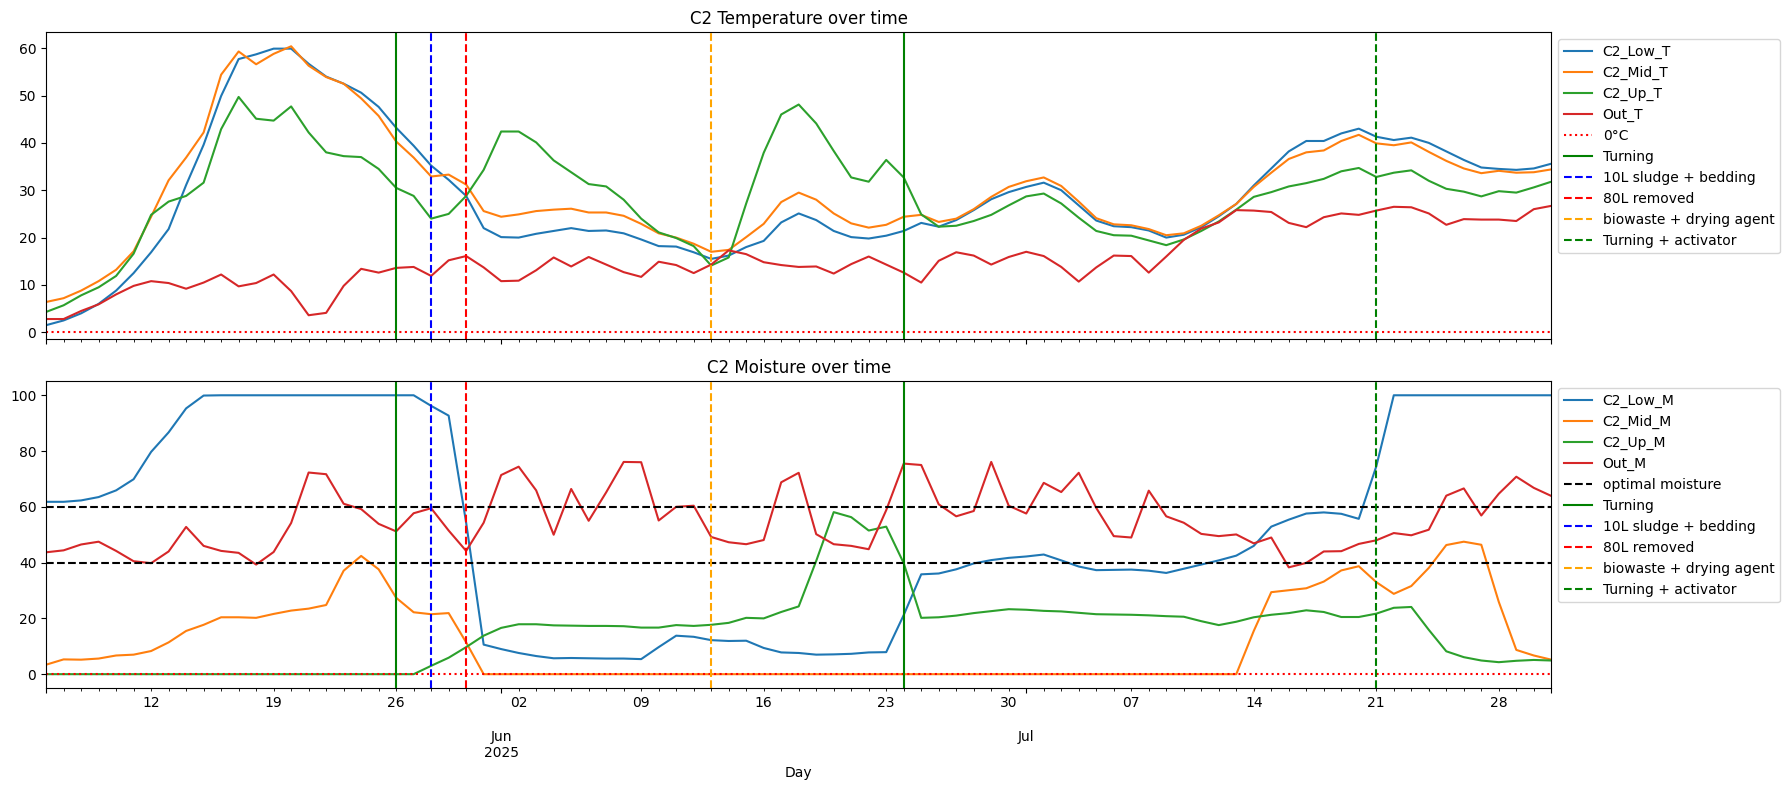

In [231]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# ---- Temperature (C2) ----
cols_T = [col for col in df.columns if (col.startswith('C2') and col.endswith('T')) or col.startswith('Out_T')]
df.set_index('Day')[cols_T].plot(ax=axes[0], title='C2 Temperature over time')

axes[0].axhline(y=0, color='r', linestyle=':', label='0°C')

vlines = [
    ('2025-05-26', 'g', '-', 'Turning'),
    ('2025-05-28', 'b', '--', '10L sludge + bedding'),
    ('2025-05-30', 'r', '--', '80L removed'),
    ('2025-06-13', 'orange', '--', 'biowaste + drying agent'),
    ('2025-06-24', 'g', '-', None),
    ('2025-07-21', 'g', '--', 'Turning + activator')
]

for date, color, style, label in vlines:
    axes[0].axvline(pd.to_datetime(date), color=color, linestyle=style, label=label)

axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))


# ---- Moisture (C2) ----
cols_M = [col for col in df.columns if (col.startswith('C2') and col.endswith('M')) or col.startswith('Out_M')]
df.set_index('Day')[cols_M].plot(ax=axes[1], title='C2 Moisture over time')

axes[1].axhline(y=0, color='r', linestyle=':')
axes[1].axhline(y=40, color='black', linestyle='--', label='optimal moisture')
axes[1].axhline(y=60, color='black', linestyle='--')

for date, color, style, label in vlines:
    axes[1].axvline(pd.to_datetime(date), color=color, linestyle=style, label=label)

axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))


plt.tight_layout()
plt.show()

In [232]:
df["Out_T"].min()

np.float64(2.8)

<h3 style="color: red"><b>Results and summary:</b></h3>

<h3><strong>Overview</strong></h3>
The chart tracks moisture levels across six sensor positions in two composters (C1 and C2) at three vertical layers each: Low, Mid, and Upper.

<h3><strong>Key Observations</strong></h3> <h4><strong>Dry hemp as a structural component</strong></h4> Dry hemp appears to function effectively as a bulking agent, improving aeration and providing carbon for microbial activity. However, when added dry and not sufficiently mixed, it contributes to uneven moisture distribution, leading to dry upper layers and wetter lower zones.
<h4><strong>Moisture distribution</strong></h4> Moisture trends indicate a clear stratification within the composters. Lower layers tend to retain significantly more moisture over time, while middle and upper layers remain comparatively dry. Although the exact moisture values may be inaccurate due to sensor limitations, the overall pattern is consistent.

This suggests that water is accumulating in the bottom layers, likely due to gravity and leachate movement, while the upper layers are not receiving or retaining sufficient moisture.

Excess moisture can also overtime lead to anaerobic pockets (lack of oxygen), resulting in the death of microbial activity.

Excess moisture may also have contributed to the rotting smell that was reported when the composters were turned and activator was added on 21 July.

<h4><strong>Temperature development</strong></h4> Temperature data shows a strong initial peak of around 60 °C, indicating a healthy microbial response at the start of the composting process. This confirms that the combination of biowaste and hemp provides suitable conditions for thermophilic activity.

However, temperatures decline relatively quickly after this peak and gradually approach ambient levels. A smaller secondary increase in temperature is observed later, but it is weaker and less sustained.

<h4><strong>Temperature–moisture relationship</strong></h4> The temperature trends closely reflect the moisture imbalance. The initial high temperatures correspond to a period when conditions were more favorable across the compost mass. As moisture became unevenly distributed, microbial activity decreased, particularly in the drier upper layers.

Later-stage activity appears to be concentrated mainly in the lower layers, where moisture levels remained more stable. This results in reduced overall efficiency, as composting is no longer occurring uniformly throughout the material.

<h4><strong>Overall interpretation</strong></h4> The composting process is biologically active and starts under favorable conditions, but its performance declines due to physical and operational factors rather than material composition.

The main limiting factors are:

Overcrowding, especially at the beginning, reducing aeration
Insufficient mixing, leading to vertical stratification
Uneven moisture distribution, with wet lower layers and dry upper layers
<h4><strong>Key takeaway</strong></h4>

The system functions as intended in principle, but composting becomes uneven and localized over time, with most biological activity occurring in the lower layers due to better moisture conditions, while upper layers remain relatively inactive.

<h3 style="color: red"><b>Ideas for further improvements:</b></h3>

Turning/aerating the compost more frequently would help redistribute moisture from the saturated lower layers to the dry upper layers, bringing more sensors into the optimal 40–60% band and improving overall decomposition efficiency.